# Motility parameters of spinning cells

This script quantifies the angular cell velocity during spinning in place. 
The registration matrix must be calculated in advance with 02-incrementalRegistration.py

**Input:**

*file_directory* : The path to the folder containing the extracted transformation matrix (PhisTotal)

*file_name*      : The name of the numpy file with the saved transformation matrix 

*step*           : The step used in the registration

**Output:**

*spinning_ang_velocity.csv* : A csv file with the measured angular velocity of the cell.

In [ ]:
import os
import csv
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import linregress

### Input

In [ ]:
folder_file     = "C:\\Users\\kourkoul\\SCRIPTS\\Paper_scripts\\example_data\\"
phis_total_file = "cell_01-PhisTotal-step10.npy"
step = 10
path_to_file    = folder_file + phis_total_file
PhisTotal       = np.load(path_to_file)

### Reading the parameters file
input_parameters_path = folder_file + "parameters.csv"
input_parameters = pd.read_csv(input_parameters_path)

### Pixel size and framerate of timelapse:
pixel_size = input_parameters["pixel_size"][0]  # μm 
fps        = input_parameters["fps"][0]         # frame rate

time_step = step / fps # in sec

output_path = folder_file + "\\output_motility\\"
if not os.path.exists(output_path):
    os.makedirs(output_path)

### Angular velocity

Angular velocity: 2.6544840472642326 +/- 0.023656385550793285 rad/sec
R^2 = 0.9961234464951522


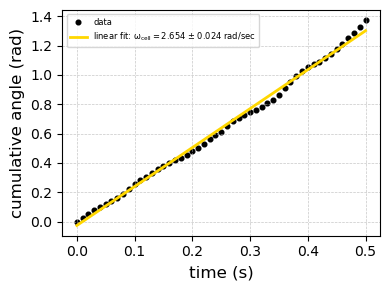

In [13]:
# Calculate the angle from the transformation matrix:
angles_radians = []
for matrix in PhisTotal:
    sin_theta = matrix[2, 1]
    cos_theta = matrix[1, 1]
    theta = np.arctan2(sin_theta, cos_theta)
    angles_radians.append(theta)

angles_radians = np.unwrap(angles_radians)
angles_degrees = np.degrees(angles_radians)
    
    
# Calculate instant angular velocity (optional):
angular_velocity = np.diff(angles_radians) / time_step
    
# Prepare time axis in seconds or frames for the plots:
time_seconds = np.arange(len(angles_degrees)) * time_step
    
# Calculate the angular velocity with linear regression:
slope, intercept, r_value, p_value, std_err = linregress(time_seconds, angles_radians)
theta_fit = slope * time_seconds + intercept
    
print('Angular velocity: ' + str(slope) + " +/- " + str(std_err) + " rad/sec")
print('R^2 = ' + str(r_value**2))

fig, ax = plt.subplots(figsize=(4, 3)) 
ax.scatter(time_seconds, angles_radians, color='black', marker='.', label="data", s=45)
ax.plot(time_seconds, theta_fit, color='gold', linestyle='-', lw=2, label="linear fit: \u03C9$_\mathrm{cell}=$" + str(round(slope,3)) + " ± " + str(round(std_err,3)) + " rad/sec" )
ax.set_xlabel('time (s)', fontsize=12)
ax.set_ylabel('cumulative angle (rad)', fontsize=12)
ax.grid(True, linestyle='--', linewidth=0.5, alpha=0.7)
ax.tick_params(axis='both', which='major', labelsize=10)
ax.legend(loc='upper left', fontsize=6)
plt.tight_layout()
plt.show()


### Saving output

In [16]:
headers = ["slope (rad/sec)", "intercept (rad)", "r_value", "p_value", "std_err (rad/sec)"]
values = [slope, intercept, r_value, p_value, std_err]

with open(output_path +'spinning_ang_velocity.csv', mode='w', newline='') as file:
    writer = csv.writer(file)
    writer.writerow(headers)
    writer.writerow(values)